# 02_Model_Training
# Diabetes Classification Models

In [1]:
# 导入包
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint
from scipy.stats import uniform

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    RepeatedStratifiedKFold)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
# 创建存放结果的文件夹
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# 数据
df = pd.read_csv(
    "diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

TARGET = "Diabetes_binary"

X = df.drop(columns=[TARGET])
y = df[TARGET]

In [3]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (56553, 21)
Test : (14139, 21)


In [4]:
# 交叉验证（Cross-Validation, CV）
cv = RepeatedStratifiedKFold(
    n_splits=5,     # 5折
    n_repeats=1,    # 重复一次
    random_state=42)

# 模型与参数空间
models = {}

# Logistic Regression
models["Logistic Regression"] = {
    "model": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, random_state=42))
    ]),
    "params": {
        "clf__C": uniform(0.01,10),
        "clf__penalty": ["l2"]},
    "n_iter":10
}

# Decision Tree
models["Decision Tree"] = {
    "model": DecisionTreeClassifier(random_state=42),
    "params": {
        "max_depth": randint(3,20),
        "min_samples_split": randint(2,30),
        "min_samples_leaf": randint(1,20)
    },
    "n_iter":20
}

# Random Forest
models["Random Forest"] = {
    "model": RandomForestClassifier(random_state=42, n_jobs=-1),
    "params": {
        "n_estimators": randint(200,600),
        "max_depth": randint(5,20),
        "min_samples_split": randint(2,20),
        "min_samples_leaf": randint(1,10)
    },
    "n_iter":20
}

# Extra Trees

models["Extra Trees"] = {

    "model": ExtraTreesClassifier(random_state=42, n_jobs=-1),

    "params": {
        "n_estimators": randint(200,600),
        "max_depth": randint(5,20),
        "min_samples_split": randint(2,20),
        "min_samples_leaf": randint(1,10)
    },

    "n_iter":20
}

# Gradient Boosting
models["Gradient Boosting"] = {
    "model": GradientBoostingClassifier(random_state=42),
    "params": {
        "n_estimators": randint(100,400),
        "learning_rate": uniform(0.01,0.2),
        "max_depth": randint(2,8)
        },
    "n_iter":20
}

# SVM
models["SVM"] = {
    "model": Pipeline([
        ("scaler",StandardScaler()),
        ("clf",SVC(probability=True, random_state=42))
    ]),
    "params": {
        "clf__C": uniform(0.1,10),
        "clf__gamma": ["auto"]
    },
    "n_iter":10
}

# XGBoost
models["XGBoost"] = {
    "model": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        tree_method="hist",
        n_jobs=-1
    ),
    "params": {
        "n_estimators": randint(100,500),
        "max_depth": randint(3,10),
        "learning_rate": uniform(0.01,0.2),
        "subsample": uniform(0.7,0.3),
        "colsample_bytree": uniform(0.7,0.3)
    },
    "n_iter":20
}

# LightGBM
models["LightGBM"] = {
    "model": LGBMClassifier(random_state=42,verbose=1),
    "params": {
        "n_estimators": randint(100,500),
        "num_leaves": randint(20,100),
        "learning_rate": uniform(0.01,0.2),
        "max_depth": randint(3,12)
    },
    "n_iter":10
}

In [5]:
# 模型训练
performance = []
best_models = {}
predictions = {}

for name, info in models.items():

    print("\n"+"="*60)
    print(name)
    print("="*60)

    search = RandomizedSearchCV(
        estimator=info["model"],
        param_distributions=info["params"],
        n_iter=info["n_iter"],
        scoring="roc_auc",
        cv=cv,
        n_jobs=32,
        random_state=42,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    print("\nBest Parameters:")
    print(search.best_params_)

    best_models[name] = best_model

 
    # Prediction
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:,1]

    predictions[name] = {
        "y_pred":y_pred,
        "y_prob":y_prob
    }

    # 评价指标计算
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    performance.append([name, acc, precision, recall, f1, auc, ap])


Logistic Regression
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'clf__C': np.float64(9.51714306409916), 'clf__penalty': 'l2'}

Decision Tree
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 5}

Random Forest
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 8, 'n_estimators': 321}

Extra Trees
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'max_depth': 19, 'min_samples_leaf': 3, 'min_samples_split': 15, 'n_estimators': 280}

Gradient Boosting
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
{'learning_rate': np.float64(0.038573363584388155), 'max_depth': 4, 'n_estimators': 249}

SVM
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'clf__C': np.float64(0.6808361216819946), '

In [6]:
# Performance Table
performance_df = pd.DataFrame(
    performance,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"])

performance_df = performance_df.sort_values("ROC_AUC", ascending=False)
print("\n")
print(performance_df)

performance_df.to_csv("results/performance_summary.csv", index=False)



                 Model  Accuracy  Precision    Recall        F1   ROC_AUC  \
6              XGBoost  0.751750   0.730714  0.797284  0.762549  0.830982   
7             LightGBM  0.752670   0.730869  0.799830  0.763796  0.830250   
4    Gradient Boosting  0.753165   0.732372  0.797850  0.763710  0.830241   
2        Random Forest  0.749629   0.728119  0.796718  0.760875  0.828316   
3          Extra Trees  0.747083   0.726026  0.793606  0.758313  0.823368   
0  Logistic Regression  0.745809   0.737201  0.763899  0.750313  0.823219   
5                  SVM  0.750336   0.725099  0.806338  0.763563  0.819065   
1        Decision Tree  0.739939   0.717715  0.790918  0.752541  0.815352   

     PR_AUC  
6  0.805993  
7  0.803908  
4  0.804390  
2  0.802115  
3  0.795218  
0  0.792225  
5  0.778664  
1  0.785317  


In [7]:
# Save Models
joblib.dump(
    {
        "X_train":X_train,
        "X_test":X_test,
        "y_train":y_train,
        "y_test":y_test
    },
    "results/data_split.pkl"
)
joblib.dump(best_models, "results/best_models.pkl")
joblib.dump(predictions, "results/predictions.pkl")

['results/predictions.pkl']

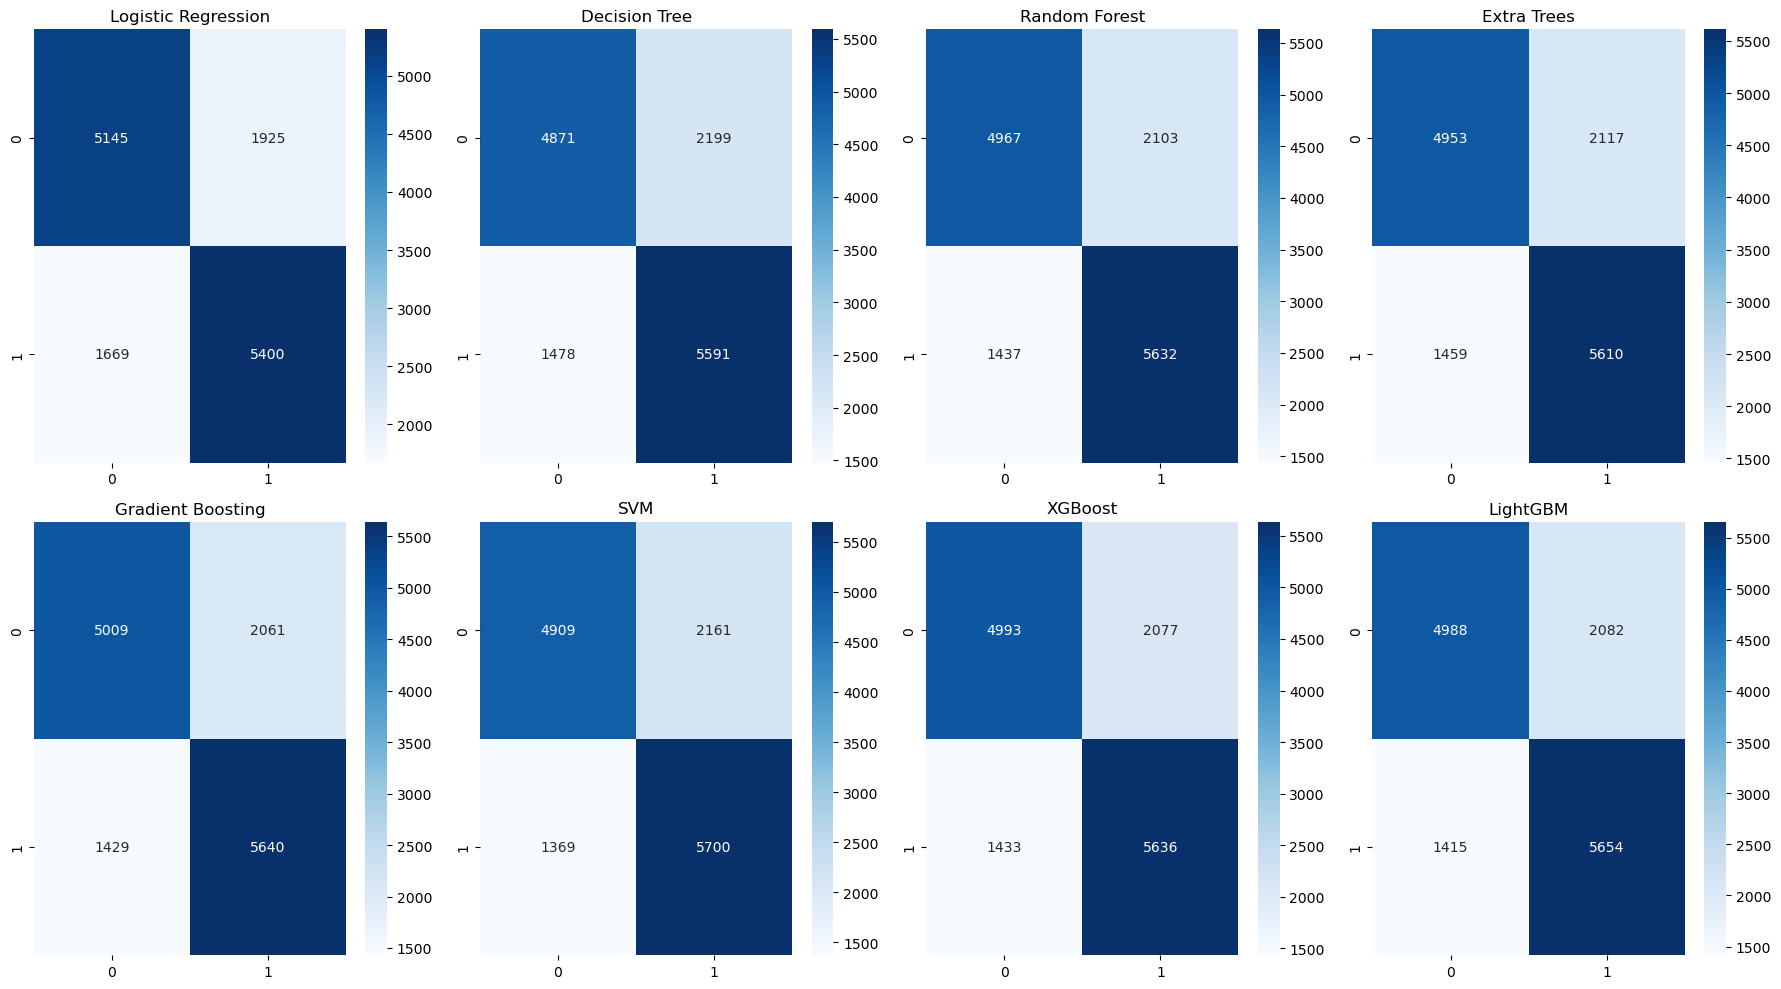

In [8]:
# Confusion Matrix
fig, axes = plt.subplots(2, 4, figsize=(18,10))
axes = axes.flatten()

for ax, name in zip(
    axes,
    best_models.keys()
):
    cm = confusion_matrix(
        y_test,
        predictions[name]["y_pred"]
    )
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax)
    ax.set_title(name)

plt.tight_layout()

plt.savefig(
    "figures/Confusion_Matrices.png",
    dpi=300)

plt.show()

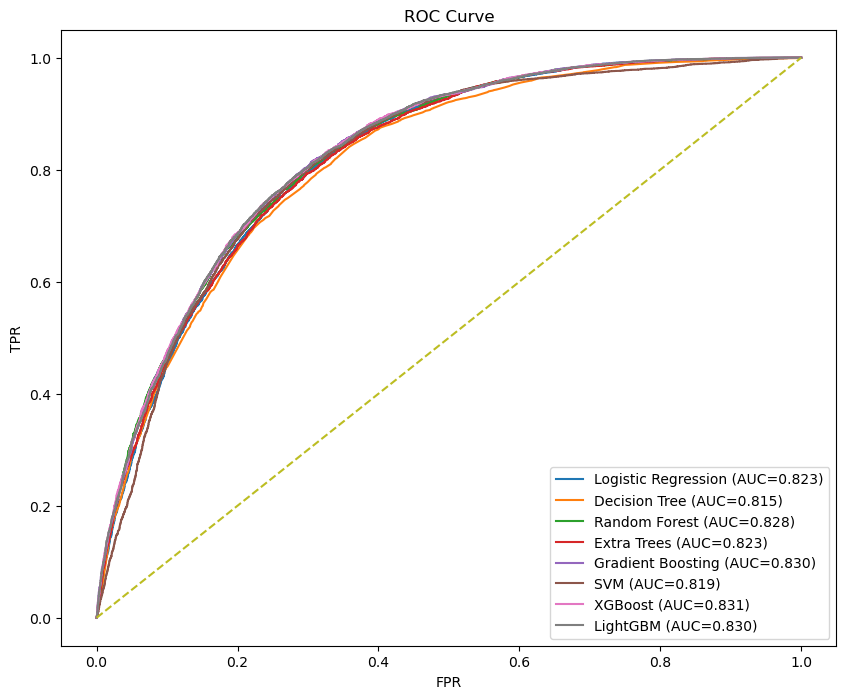

In [9]:
# ROC Curves
plt.figure(figsize=(10,8))

for name in best_models:
    y_prob = predictions[name]["y_prob"]
    fpr,tpr,_ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
)

plt.plot([0,1], [0,1], "--")

plt.legend()

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("ROC Curve")

plt.savefig(
    "figures/ROC_Curves.png",
    dpi=300)

plt.show()

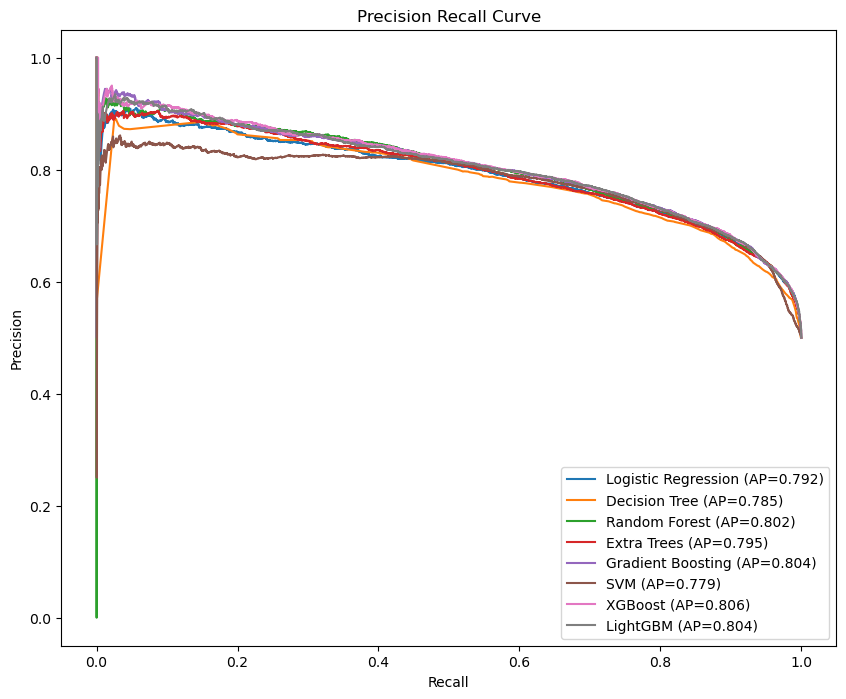


训练完成


In [10]:
# PR Curve

plt.figure(figsize=(10,8))

for name in best_models:
    y_prob = predictions[name]["y_prob"]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    ap = average_precision_score(y_test, y_prob)

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})")

plt.legend()

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.savefig("figures/PR_Curves.png", dpi=300)

plt.show()

print("\n训练完成")